100%|██████████| 8.70k/8.70k [00:00<00:00, 1.78MB/s]

Extracting files...
Dataset downloaded at: C:\Users\lenovo\.cache\kagglehub\datasets\spscientist\students-performance-in-exams\versions\1
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Dataset shape: (1000,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype

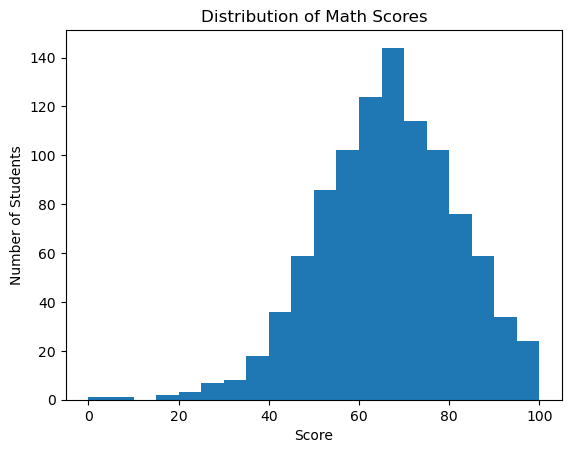

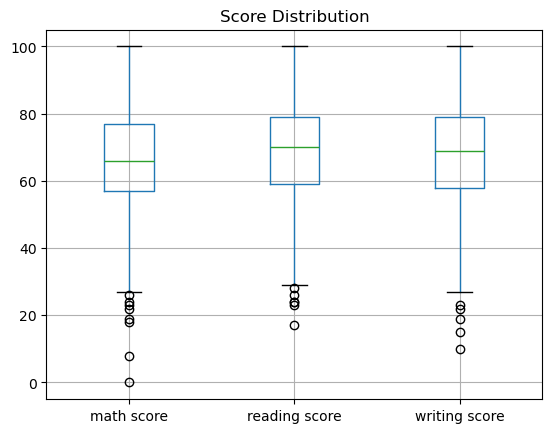

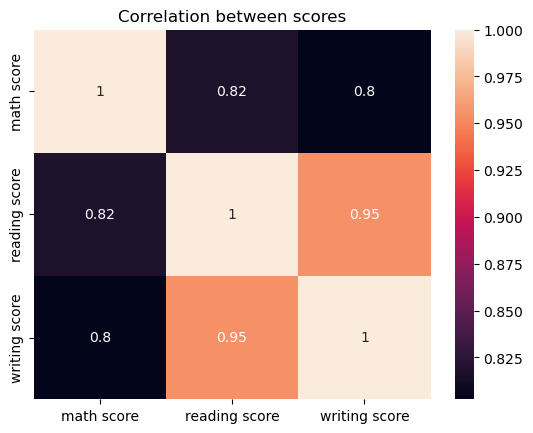

   average_score  pass_fail
0      72.666667          1
1      82.333333          1
2      92.666667          1
3      49.333333          0
4      76.333333          1


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


cluster
0    444
2    308
1    248
Name: count, dtype: int64


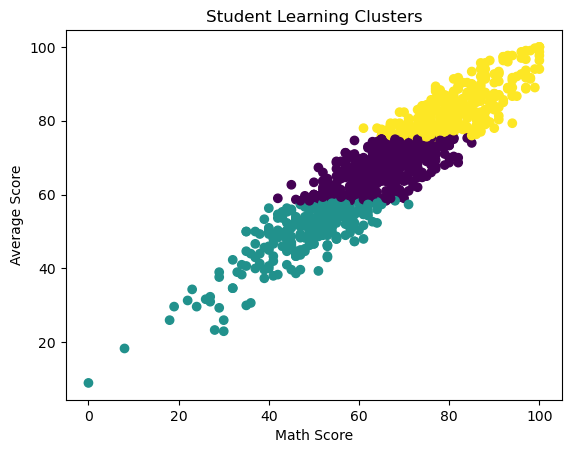

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00       173

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00       173

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



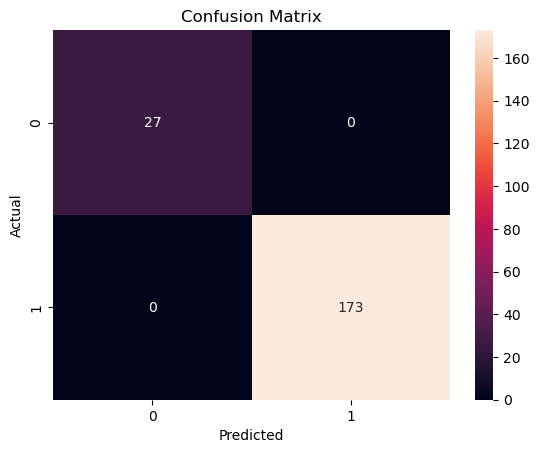

Cross Validation Scores: [1.    1.    0.995 1.    1.   ]
Average Accuracy: 0.999


In [3]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ===============================
# 2. DOWNLOAD DATASET FROM KAGGLE
# ===============================

# This downloads the dataset automatically
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Dataset downloaded at:", path)


# ===============================
# 3. LOAD DATASET
# ===============================

# The dataset contains a CSV file
df = pd.read_csv(path + "/StudentsPerformance.csv")

# Show first 5 rows
print(df.head())


# ===============================
# 4. BASIC DATA EXPLORATION
# ===============================

# Check dataset shape
print("Dataset shape:", df.shape)

# Check data types
print(df.info())

# Check missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())


# ===============================
# 5. EXPLORATORY DATA ANALYSIS
# ===============================

# Distribution of math scores
plt.hist(df["math score"], bins=20)
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.show()


# Boxplot for all scores
df[["math score","reading score","writing score"]].boxplot()
plt.title("Score Distribution")
plt.show()


# Correlation heatmap
sns.heatmap(df[["math score","reading score","writing score"]].corr(), annot=True)
plt.title("Correlation between scores")
plt.show()


# ===============================
# 6. CREATE PASS / FAIL TARGET
# ===============================

# We consider pass if average score >= 50

df["average_score"] = (
    df["math score"] + df["reading score"] + df["writing score"]
) / 3

df["pass_fail"] = (df["average_score"] >= 50).astype(int)

print(df[["average_score","pass_fail"]].head())


# ===============================
# 7. ENCODE CATEGORICAL VARIABLES
# ===============================

# Convert text columns into numbers
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])


# ===============================
# 8. UNSUPERVISED LEARNING (CLUSTERING)
# ===============================

# Features for clustering
cluster_features = df[
    ["math score","reading score","writing score","average_score"]
]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)


# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

print(df["cluster"].value_counts())


# ===============================
# 9. VISUALIZE CLUSTERS
# ===============================

plt.scatter(
    df["math score"],
    df["average_score"],
    c=df["cluster"]
)

plt.xlabel("Math Score")
plt.ylabel("Average Score")
plt.title("Student Learning Clusters")
plt.show()


# ===============================
# 10. PREPARE DATA FOR PREDICTION
# ===============================

# Features
X = df.drop(columns=["pass_fail"])

# Target
y = df["pass_fail"]


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ===============================
# 11. LOGISTIC REGRESSION MODEL
# ===============================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))


# ===============================
# 12. RANDOM FOREST MODEL
# ===============================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))


# ===============================
# 13. CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===============================
# 14. CROSS VALIDATION
# ===============================

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", cv_scores)

print("Average Accuracy:", np.mean(cv_scores))